# Task 2 & 3 (Player Style) — Thống kê mô tả, Trực quan hóa & Khám phá dữ liệu (EDA)

**Input:** `player_style_features_pl_laliga_seriea_1516.csv` — output Task 1 (1016 cầu thủ, Premier League + La Liga + Serie A mùa 2015/2016, đã lọc ≥900 phút thi đấu).

**Khác biệt quan trọng so với EDA ở bài Shot Zone:** đơn vị phân tích giờ là **1 cầu thủ/mùa** (không phải 1 sự kiện), nên các khái niệm gắn với chuỗi thời gian trong trận đấu (Moving Average theo phút, Control Chart theo trận) không còn áp dụng tự nhiên — notebook này tập trung vào các kỹ thuật phù hợp với dữ liệu dạng "profile nhiều chiều": phân phối, dispersion, tương quan/đa cộng tuyến, và đối chiếu với vị trí thi đấu thật (`primary_position`) để sanity-check trước khi bước vào clustering.


## 0 — Setup

In [15]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

CSV_PATH = "/kaggle/working/player_style_features_pl_laliga_seriea_1516.csv"
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df.shape


(1016, 36)

In [16]:
FEATURE_COLS = [
    "shots_p90", "np_goals_p90", "avg_shot_distance", "dribbles_p90", "dribble_success_rate",
    "touches_p90", "touches_in_box_p90", "passes_p90", "pass_completion_pct", "key_passes_p90",
    "assists_p90", "crosses_p90", "through_balls_p90", "long_balls_p90", "avg_pass_length",
    "pressures_p90", "tackles_p90", "tackle_success_rate", "interceptions_p90",
    "interception_success_rate", "ball_recoveries_p90", "clearances_p90", "aerial_won_p90",
    "fouls_committed_p90", "fouls_won_p90", "avg_location_x", "avg_location_y",
    "std_location_x", "std_location_y",
]
print(len(FEATURE_COLS), "feature numeric")


29 feature numeric


---
# TASK 2 — Trực quan hóa cơ bản & Thống kê mô tả

## 2.1 — Tổng quan dữ liệu

In [17]:
print("Shape:", df.shape)
df.head(3)


Shape: (1016, 36)


,player_id,player_name,primary_team,competitions_played,n_matches_played,total_minutes_played,shots_p90,np_goals_p90,avg_shot_distance,dribbles_p90,...,ball_recoveries_p90,clearances_p90,aerial_won_p90,fouls_committed_p90,fouls_won_p90,avg_location_x,avg_location_y,std_location_x,std_location_y,primary_position
0,3339,Asmir Begović,Chelsea,Premier League,17,1472.0,0.000000,0.000000,NaN,0.000000,...,3.362772,0.000000,0.000000,0.000000,0.244565,9.588953,40.169961,6.030542,7.832626,Goalkeeper
1,5594,Branislav Ivanović,Chelsea,Premier League,33,3057.0,0.824338,0.058881,18.956525,0.529931,...,3.562316,3.856722,2.796860,1.148184,0.706575,60.060169,59.562310,27.428947,20.427508,Right Back
2,3456,Kurt Happy Zouma,Chelsea,Premier League,23,2013.0,0.715350,0.044709,16.912380,0.357675,...,2.369598,7.555887,3.979136,0.447094,0.402385,41.311802,52.834272,21.911993,12.956491,Right Center Back


avg_shot_distance            75
interception_success_rate    72
tackle_success_rate          70
dribble_success_rate         42
dtype: int64


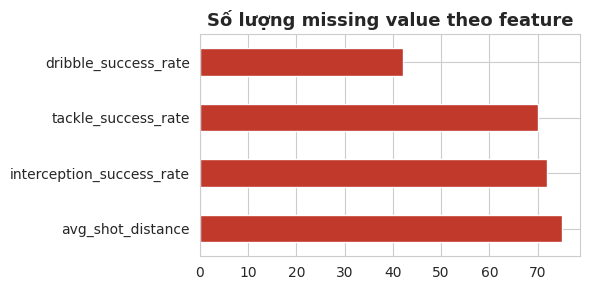

In [18]:
missing = df[FEATURE_COLS].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

fig, ax = plt.subplots(figsize=(6, 3))
missing.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Số lượng missing value theo feature")
plt.tight_layout()
plt.show()


**Giải thích missing:** đây đều là các cột **tỷ lệ thành công** (`dribble_success_rate`, `tackle_success_rate`, `interception_success_rate`) hoặc trung bình có điều kiện (`avg_shot_distance`) — `NaN` xuất hiện khi cầu thủ **chưa từng thực hiện hành động đó** trong cả mùa (ví dụ thủ môn không có `avg_shot_distance` vì không sút bóng lần nào). Đây là missing có cấu trúc, không phải lỗi dữ liệu, và cần xử lý riêng ở Task 4 (không nên impute bằng 0 một cách máy móc vì 0% thành công khác hẳn ý nghĩa với "chưa từng thử").

## 2.2 — Bar chart: phân bố vị trí thi đấu & đội bóng

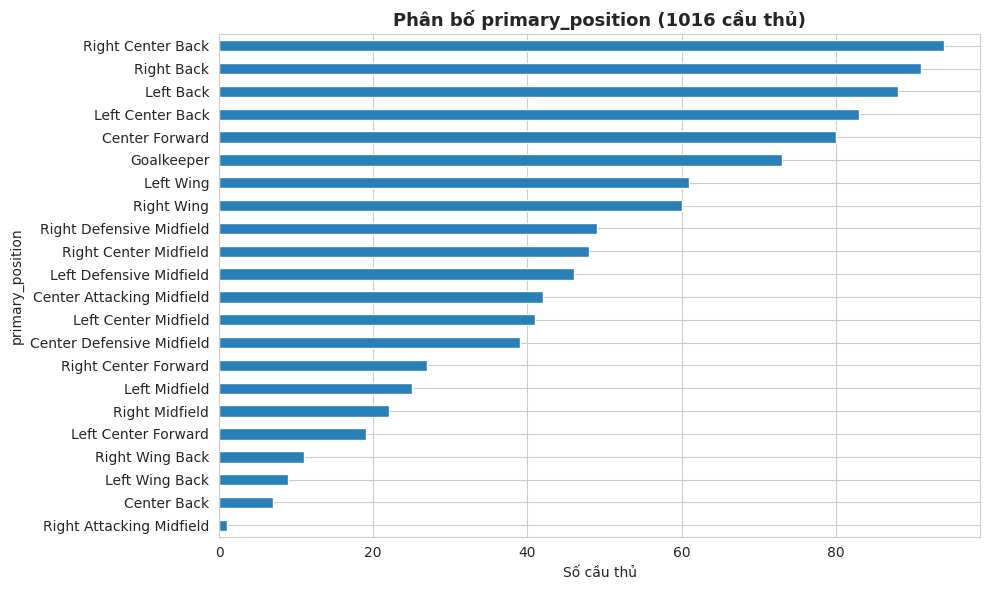

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
df["primary_position"].value_counts().sort_values().plot(kind="barh", ax=ax, color="#2980b9")
ax.set_title("Phân bố primary_position (1016 cầu thủ)")
ax.set_xlabel("Số cầu thủ")
plt.tight_layout()
plt.show()


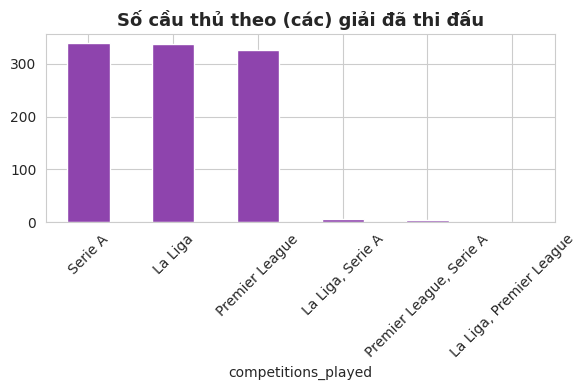

competitions_played
Serie A                    339
La Liga                    338
Premier League             327
La Liga, Serie A             6
Premier League, Serie A      5
La Liga, Premier League      1
Name: count, dtype: int64


In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
df["competitions_played"].value_counts().plot(kind="bar", ax=ax, color="#8e44ad")
ax.set_title("Số cầu thủ theo (các) giải đã thi đấu")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(df["competitions_played"].value_counts())


Một số ít cầu thủ (12/1016) thi đấu ở **2 giải khác nhau trong cùng mùa** — chuyển nhượng giữa mùa (kỳ chuyển nhượng mùa đông). `primary_team` của nhóm này chỉ phản ánh đội xuất hiện nhiều nhất, cần lưu ý khi diễn giải.

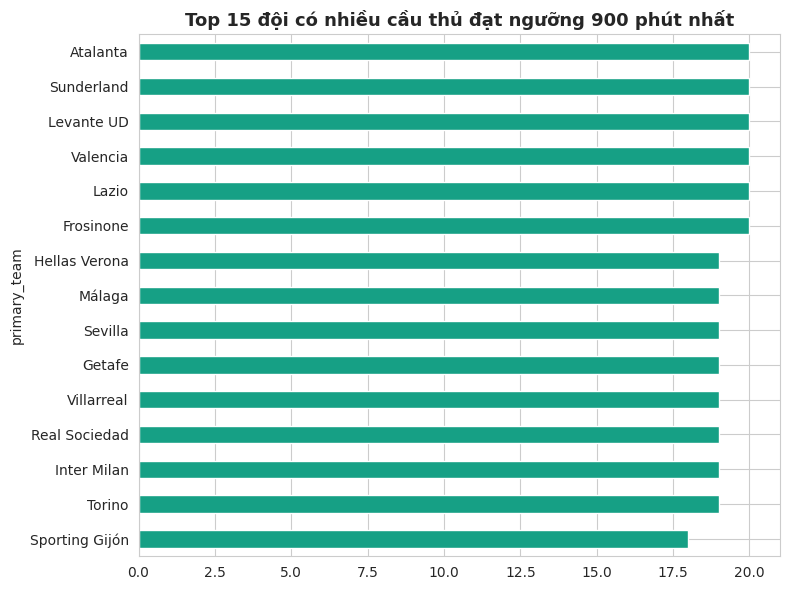

In [21]:
top_teams = df["primary_team"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_teams.sort_values().plot(kind="barh", ax=ax, color="#16a085")
ax.set_title("Top 15 đội có nhiều cầu thủ đạt ngưỡng 900 phút nhất")
plt.tight_layout()
plt.show()


## 2.3 — Histogram: phân bố các feature chính

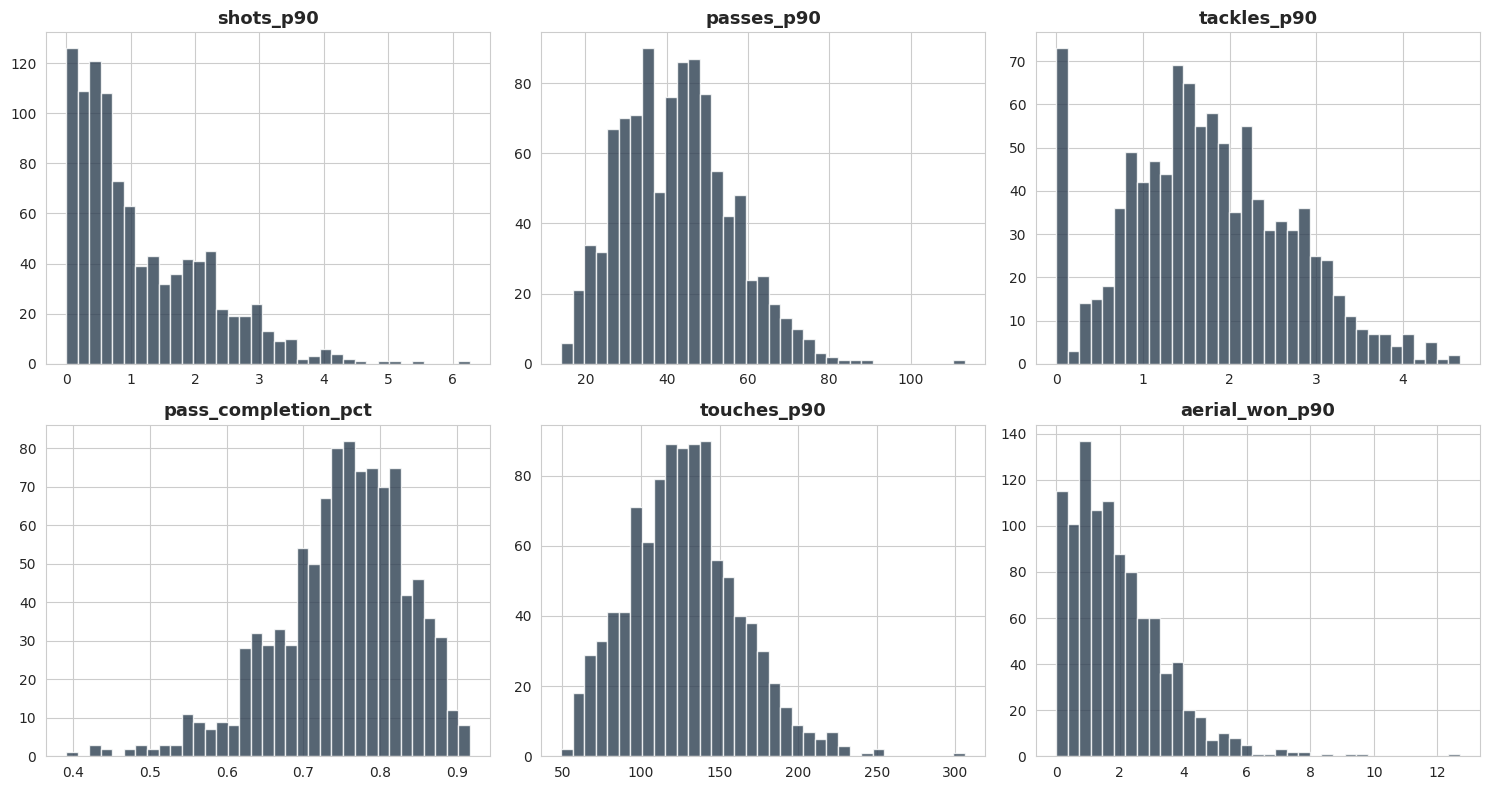

In [22]:
hist_cols = ["shots_p90", "passes_p90", "tackles_p90", "pass_completion_pct", "touches_p90", "aerial_won_p90"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, col in zip(axes, hist_cols):
    ax.hist(df[col].dropna(), bins=35, color="#2c3e50", alpha=0.8)
    ax.set_title(col)

plt.tight_layout()
plt.show()


**Quan sát nhanh:** `shots_p90` lệch phải mạnh (đa số cầu thủ ít sút, số ít tiền đạo sút rất nhiều) — hợp lý vì phần lớn 1016 cầu thủ này là hậu vệ/tiền vệ phòng ngự. `pass_completion_pct` lệch trái (đa số cầu thủ có tỷ lệ chuyền chính xác cao, chỉ số ít thấp — thường là các pha chuyền mạo hiểm/tiền đạo). `tackles_p90` và `aerial_won_p90` đều có 1 khối lớn giá trị gần 0 (cầu thủ tấn công hầu như không tắc bóng).

## 2.4 — Bảng thống kê mô tả tổng hợp

In [23]:
pd.set_option("display.max_rows", 40)
df[FEATURE_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
shots_p90,1016.0,1.161645,1.015008,0.000000,0.391995,0.816236,1.834371,6.267563
np_goals_p90,1016.0,0.108074,0.147401,0.000000,0.000000,0.059308,0.149254,1.075697
avg_shot_distance,941.0,19.431573,5.422819,5.430624,15.445829,19.716188,23.411639,35.496486
dribbles_p90,1016.0,1.608351,1.416330,0.000000,0.501956,1.254014,2.316309,7.852349
dribble_success_rate,974.0,0.611360,0.177553,0.000000,0.500000,0.583333,0.700000,1.000000
touches_p90,1016.0,127.726316,35.303290,49.315417,103.117248,125.920892,148.568910,305.988004
touches_in_box_p90,1016.0,5.074682,5.248177,0.000000,1.470705,2.861987,7.435400,30.176307
passes_p90,1016.0,42.383093,13.541413,14.099695,31.954573,42.105778,50.787161,113.332223
pass_completion_pct,1016.0,0.750014,0.085231,0.390984,0.701870,0.759497,0.809751,0.916831
key_passes_p90,1016.0,0.746255,0.603563,0.000000,0.232489,0.665103,1.086324,3.542400


## 2.5 — Đo lường độ phân tán: Std, Variance, Range, IQR

In [24]:
dispersion_rows = []
for col in FEATURE_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    dispersion_rows.append({
        "feature": col, "std": s.std(), "variance": s.var(),
        "range": s.max() - s.min(), "IQR": q3 - q1,
    })

dispersion_df = pd.DataFrame(dispersion_rows).set_index("feature")
dispersion_df


,std,variance,range,IQR
feature,,,,
shots_p90,1.015008,1.030242,6.267563,1.442376
np_goals_p90,0.147401,0.021727,1.075697,0.149254
avg_shot_distance,5.422819,29.406964,30.065861,7.965809
dribbles_p90,1.416330,2.005990,7.852349,1.814353
dribble_success_rate,0.177553,0.031525,1.000000,0.200000
touches_p90,35.303290,1246.322268,256.672587,45.451661
touches_in_box_p90,5.248177,27.543361,30.176307,5.964695
passes_p90,13.541413,183.369862,99.232528,18.832588
pass_completion_pct,0.085231,0.007264,0.525847,0.107881


**Nhận xét:** các feature toạ độ (`avg_location_x`, `avg_location_y`) có std/range tính bằng đơn vị mét sân (0-120/0-80), trong khi các tỷ lệ thành công (`pass_completion_pct`, `tackle_success_rate`...) nằm trong [0,1] — chênh lệch scale rất lớn, giống hệt vấn đề đã gặp ở bài Shot Zone. Đây tiếp tục là bằng chứng cho việc **bắt buộc phải scale dữ liệu** trước khi đưa vào K-Means ở Task 5 sắp tới.

## 2.6 — Box Plot theo vị trí thi đấu (`primary_position`)

Đây là bước "preview" quan trọng: nếu các feature per-90 đã tách biệt rõ theo vị trí thi đấu chính thức, đó là tín hiệu tốt cho thấy K-Means (không biết trước vị trí) có cơ hội tự tìm ra cấu trúc tương tự.

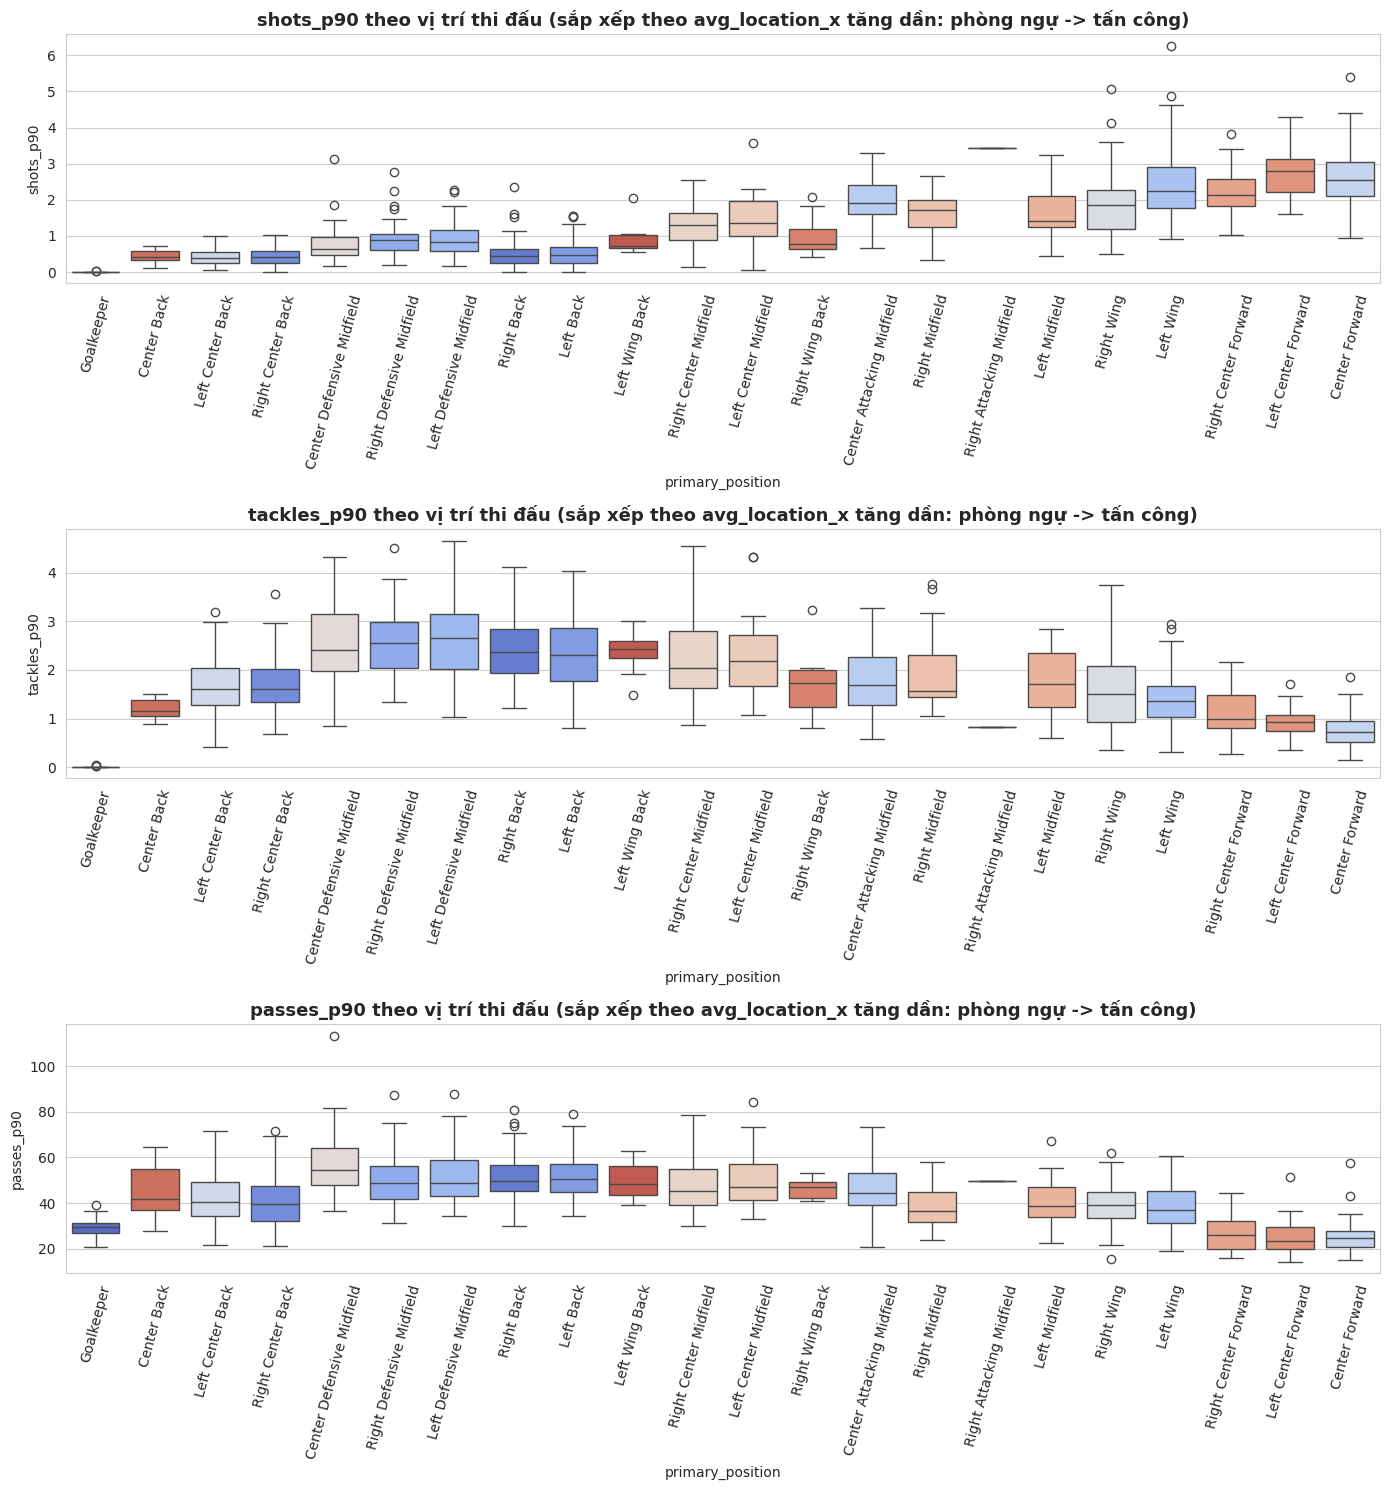

In [25]:
position_order = df.groupby("primary_position")["avg_location_x"].mean().sort_values().index

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
for ax, col in zip(axes, ["shots_p90", "tackles_p90", "passes_p90"]):
    sns.boxplot(data=df, x="primary_position", y=col, order=position_order, ax=ax, hue="primary_position", palette="coolwarm", legend=False)
    ax.set_title(f"{col} theo vị trí thi đấu (sắp xếp theo avg_location_x tăng dần: phòng ngự -> tấn công)")
    ax.tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()


**Quan sát:** `shots_p90` tăng dần rõ rệt từ vị trí phòng ngự sang tấn công, `tackles_p90` có xu hướng ngược lại — đúng như kỳ vọng bóng đá thực tế. Đây là tín hiệu tốt: các feature per-90 đã trích xuất **thực sự mang thông tin phân biệt vị trí**, không phải nhiễu ngẫu nhiên — cơ sở hợp lý để kỳ vọng K-Means có thể tìm ra cấu trúc cụm có ý nghĩa ở Task 5.

## 2.7 — Đo lường vị trí: Percentile & Z-score (tìm cầu thủ nổi bật/outlier)

In [26]:
for col in ["shots_p90", "dribbles_p90", "tackles_p90"]:
    df[f"{col}_zscore"] = stats.zscore(df[col].fillna(df[col].mean()))

print("Top 5 cầu thủ có shots_p90 nổi bật nhất (z-score cao nhất):")
print(df.sort_values("shots_p90_zscore", ascending=False)[["player_name", "primary_team", "primary_position", "shots_p90"]].head(5))

print("\nTop 5 cầu thủ có dribbles_p90 nổi bật nhất:")
print(df.sort_values("dribbles_p90_zscore", ascending=False)[["player_name", "primary_team", "primary_position", "dribbles_p90"]].head(5))

print("\nTop 5 cầu thủ có tackles_p90 nổi bật nhất:")
print(df.sort_values("tackles_p90_zscore", ascending=False)[["player_name", "primary_team", "primary_position", "tackles_p90"]].head(5))


Top 5 cầu thủ có shots_p90 nổi bật nhất (z-score cao nhất):
                             player_name primary_team primary_position  \
342  Cristiano Ronaldo dos Santos Aveiro  Real Madrid        Left Wing   
869              Gonzalo Gerardo Higuaín       Napoli   Center Forward   
676       Lionel Andrés Messi Cuccittini    Barcelona       Right Wing   
86             Philippe Coutinho Correia    Liverpool        Left Wing   
868                      Lorenzo Insigne       Napoli        Left Wing   

     shots_p90  
342   6.267563  
869   5.404157  
676   5.076758  
86    4.870795  
868   4.635635  

Top 5 cầu thủ có dribbles_p90 nổi bật nhất:
                        player_name     primary_team      primary_position  \
672   Neymar da Silva Santos Junior        Barcelona             Left Wing   
676  Lionel Andrés Messi Cuccittini        Barcelona            Right Wing   
176                   Wilfried Zaha   Crystal Palace            Right Wing   
554       Yannick Ferreira Carrasco 

## 2.8 — Skewness & Kurtosis

In [27]:
skew_kurt_rows = []
for col in FEATURE_COLS:
    s = df[col].dropna()
    skew_kurt_rows.append({
        "feature": col,
        "skewness": stats.skew(s),
        "kurtosis_excess": stats.kurtosis(s),
    })

skew_kurt_df = pd.DataFrame(skew_kurt_rows).set_index("feature").sort_values("skewness", ascending=False)
skew_kurt_df


,skewness,kurtosis_excess
feature,,
through_balls_p90,4.259456,41.076803
avg_pass_length,2.733410,7.731379
np_goals_p90,2.350533,7.898353
assists_p90,1.668237,3.440873
aerial_won_p90,1.523799,4.703398
touches_in_box_p90,1.418703,1.474850
crosses_p90,1.185224,1.094501
dribbles_p90,1.159761,1.149414
long_balls_p90,1.154917,1.781138


**Nhận xét:** các feature tấn công hiếm gặp ở phần lớn cầu thủ trong tập này (`through_balls_p90`, `assists_p90`, `crosses_p90`, `np_goals_p90`) có skewness rất cao — hợp lý vì đa số 1016 cầu thủ là hậu vệ/tiền vệ trung tâm, chỉ số ít là tiền đạo/tiền vệ cánh mới có các chỉ số này cao. Ngược lại, `pass_completion_pct` lệch âm (trần ở gần 100%). Thông tin này sẽ hữu ích khi chọn cách xử lý outlier ở Task 4 — không nên loại các giá trị cực đoan này vì chúng chính là tín hiệu phân biệt phong cách thật (tiền đạo ghi bàn nhiều), không phải nhiễu.

---
# TASK 3 — Khám phá dữ liệu chuyên sâu (EDA)

## 3.1 — Kiểm tra tính hợp lệ giá trị

In [28]:
rate_cols = ["dribble_success_rate", "pass_completion_pct", "tackle_success_rate", "interception_success_rate"]
for col in rate_cols:
    out_of_range = ~df[col].dropna().between(0, 1)
    print(f"{col}: {out_of_range.sum()} giá trị ngoài [0,1]")

invalid_x = ~df["avg_location_x"].between(0, 120)
invalid_y = ~df["avg_location_y"].between(0, 80)
print(f"avg_location_x ngoài [0,120]: {invalid_x.sum()}")
print(f"avg_location_y ngoài [0,80]: {invalid_y.sum()}")


dribble_success_rate: 0 giá trị ngoài [0,1]
pass_completion_pct: 0 giá trị ngoài [0,1]
tackle_success_rate: 0 giá trị ngoài [0,1]
interception_success_rate: 0 giá trị ngoài [0,1]
avg_location_x ngoài [0,120]: 0
avg_location_y ngoài [0,80]: 0


## 3.2 — Heatmap tương quan (29 feature) & phát hiện đa cộng tuyến

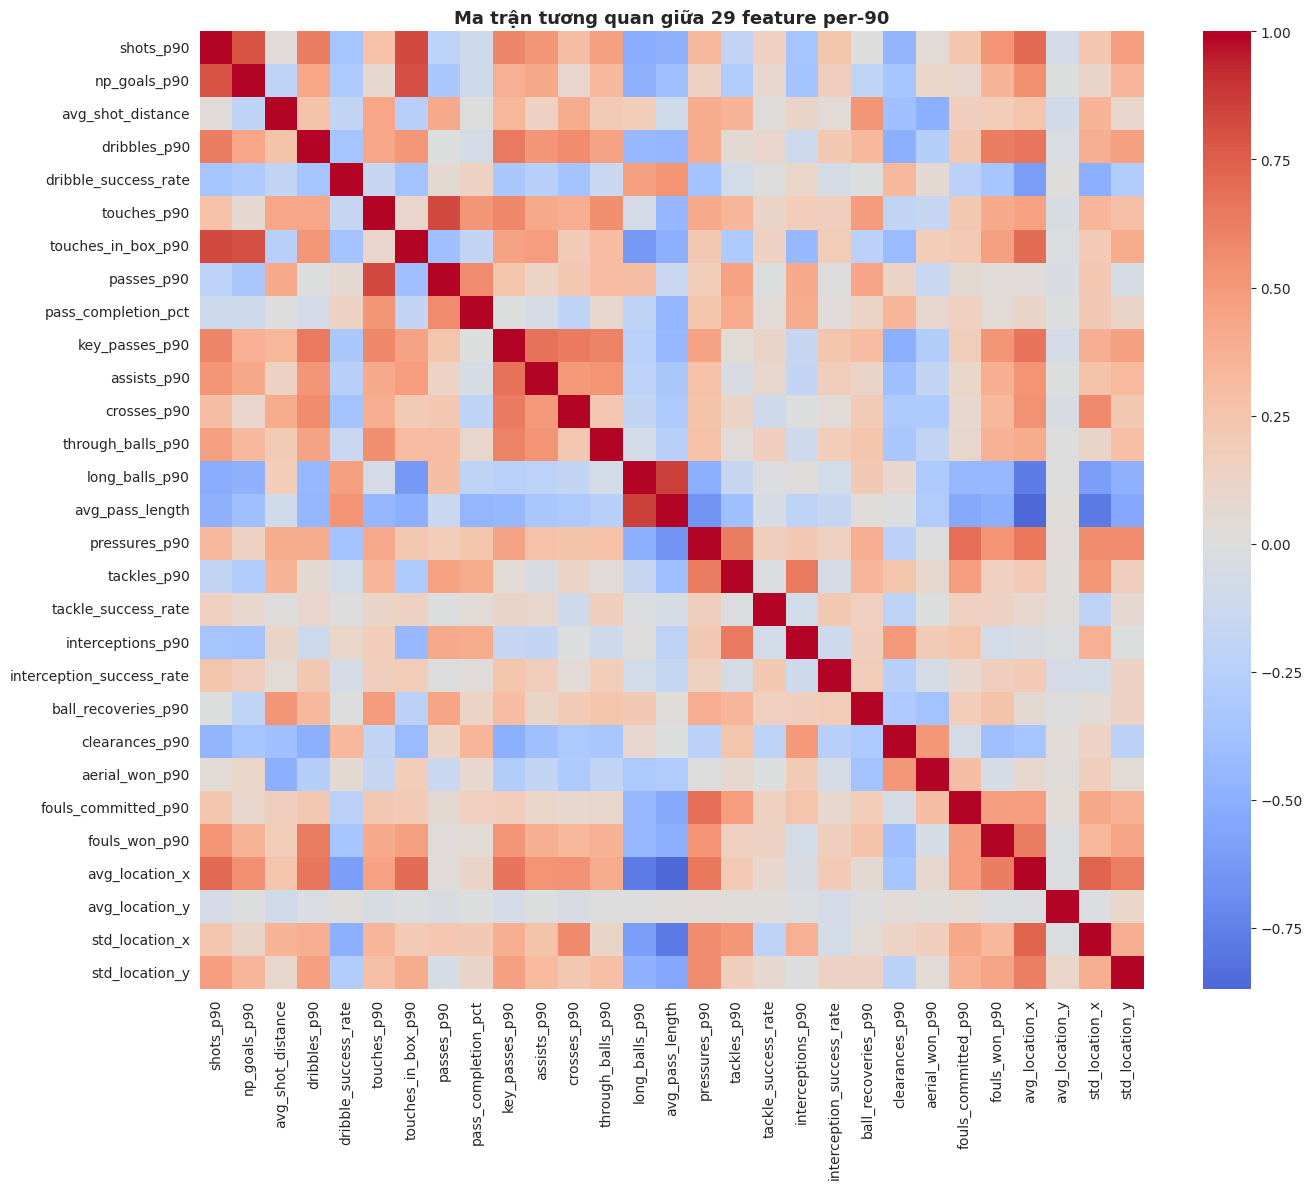

In [29]:
corr_matrix = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Ma trận tương quan giữa 29 feature per-90")
plt.tight_layout()
plt.show()


In [30]:
pairs = []
cols = FEATURE_COLS
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.75:
            pairs.append((cols[i], cols[j], round(r, 3)))
pairs.sort(key=lambda x: -abs(x[2]))
pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"])


,feature_1,feature_2,correlation
0,avg_pass_length,avg_location_x,-0.870
1,long_balls_p90,avg_pass_length,0.858
2,touches_p90,passes_p90,0.832
3,shots_p90,touches_in_box_p90,0.827
4,np_goals_p90,touches_in_box_p90,0.811
5,shots_p90,np_goals_p90,0.794
6,avg_pass_length,std_location_x,-0.778
7,long_balls_p90,avg_location_x,-0.772


**Đọc kết quả:** không có cặp nào tương quan gần như tuyệt đối (>0.9) — khác với bài Shot Zone (nơi `location_x` và `distance_to_goal` tương quan tới 0.93, buộc phải loại bớt 1 biến). Ở đây cặp cao nhất là `avg_pass_length` vs `avg_location_x` (r≈−0.87): hậu vệ (avg_location_x thấp) có xu hướng chuyền dài hơn (phá bóng/chuyền vượt tuyến), tiền đạo (avg_location_x cao) chuyền ngắn hơn — đây là **quan hệ thật giữa 2 khái niệm khác nhau** (vị trí trung bình vs kỹ thuật chuyền bóng), không phải trùng lặp thông tin, nên **không cần loại feature nào** trước khi sang Task 4. Cặp `touches_p90` vs `passes_p90` (r≈0.83) cũng đáng chú ý (chuyền bóng là 1 tập con lớn của chạm bóng) nhưng vẫn mang thêm thông tin riêng (touches còn gồm dribble, carry, shot...) nên vẫn giữ cả hai.

## 3.3 — Trực quan không gian: vị trí trung bình trên sân theo nhóm vị trí thi đấu

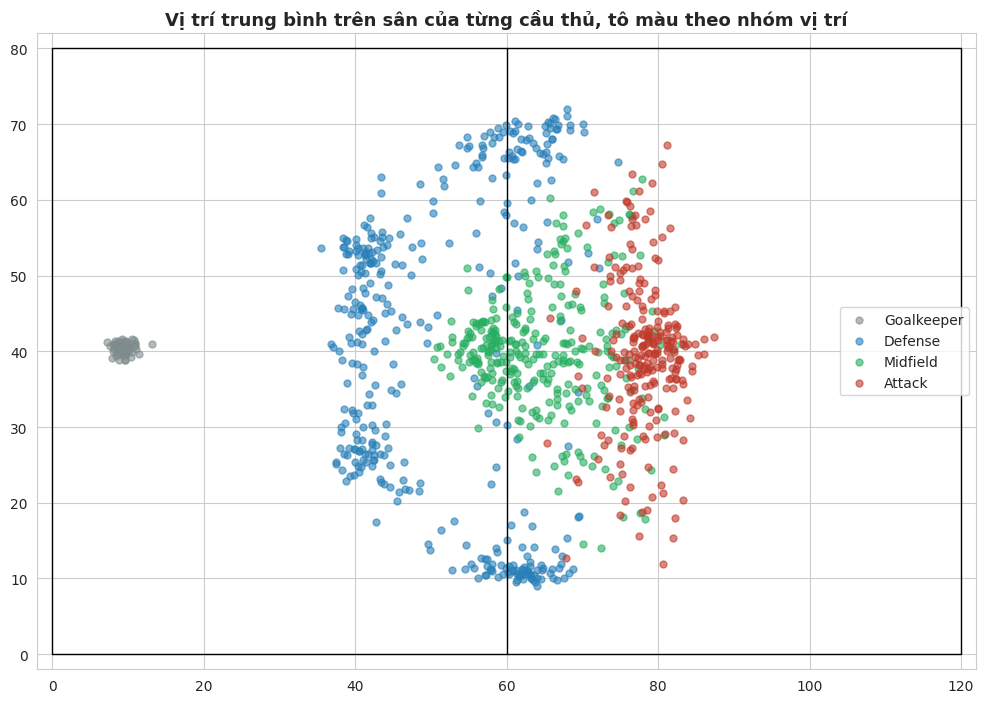

In [31]:
position_group_map = {
    "Goalkeeper": "Goalkeeper",
    "Center Back": "Defense", "Left Center Back": "Defense", "Right Center Back": "Defense",
    "Left Back": "Defense", "Right Back": "Defense",
    "Left Wing Back": "Defense", "Right Wing Back": "Defense",
    "Center Defensive Midfield": "Midfield", "Left Defensive Midfield": "Midfield", "Right Defensive Midfield": "Midfield",
    "Center Attacking Midfield": "Midfield", "Left Center Midfield": "Midfield", "Right Center Midfield": "Midfield",
    "Left Midfield": "Midfield", "Right Midfield": "Midfield", "Right Attacking Midfield": "Midfield",
    "Center Forward": "Attack", "Left Center Forward": "Attack", "Right Center Forward": "Attack",
    "Left Wing": "Attack", "Right Wing": "Attack",
}
df["position_group"] = df["primary_position"].map(position_group_map)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color="black", linewidth=1)
ax.plot([60, 60], [0, 80], color="black", linewidth=1)

palette = {"Goalkeeper": "#7f8c8d", "Defense": "#2980b9", "Midfield": "#27ae60", "Attack": "#c0392b"}
for group, color in palette.items():
    sub = df[df["position_group"] == group]
    ax.scatter(sub["avg_location_x"], sub["avg_location_y"], s=25, alpha=0.6, color=color, label=group)

ax.set_xlim(-2, 122)
ax.set_ylim(-2, 82)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Vị trí trung bình trên sân của từng cầu thủ, tô màu theo nhóm vị trí")
plt.tight_layout()
plt.show()


**Sanity check tốt:** 4 nhóm vị trí tách thành các dải rõ rệt theo trục x (Goalkeeper gần x=0, Defense, Midfield, Attack tăng dần) mà không cần bất kỳ thuật toán clustering nào — xác nhận `avg_location_x`/`avg_location_y` mang đúng thông tin không gian kỳ vọng.

## 3.4 — Correlation vs Regression

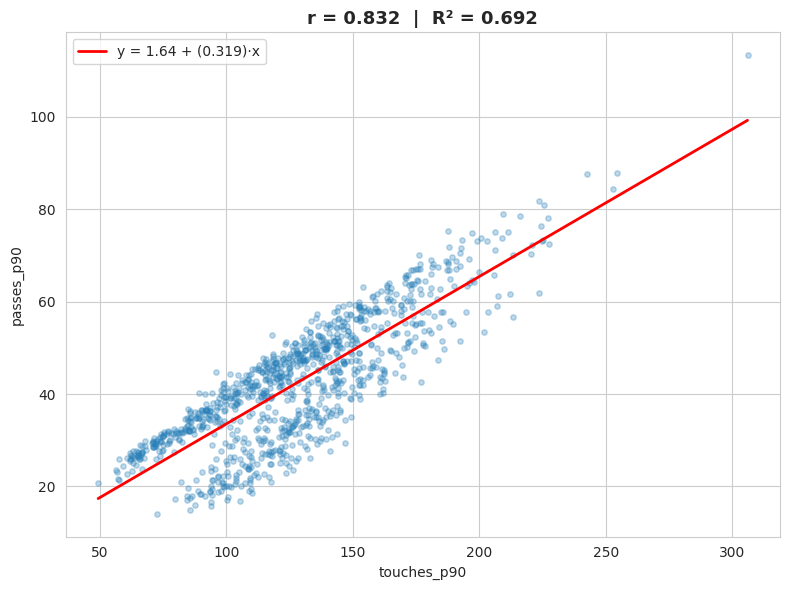

In [32]:
x = df["touches_p90"].values
y = df["passes_p90"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.3, color="#2980b9", s=15)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, intercept + slope * x_line, color="red", linewidth=2,
        label=f"y = {intercept:.2f} + ({slope:.3f})·x")
ax.set_xlabel("touches_p90")
ax.set_ylabel("passes_p90")
ax.set_title(f"r = {r_value:.3f}  |  R² = {r_value**2:.3f}")
ax.legend()
plt.tight_layout()
plt.show()


**Diễn giải:** r≈0.83 (R²≈0.69) — khoảng 69% biến thiên của `passes_p90` giải thích được từ `touches_p90`, phần còn lại (~31%) đến từ tỷ lệ chuyền/chạm khác nhau giữa các vị trí (ví dụ tiền đạo chạm bóng nhiều để dribble/sút, không phải để chuyền). Hệ số tương quan chỉ nói lên **mức độ liên hệ tuyến tính**; phương trình hồi quy mới là công cụ **dự đoán cụ thể** — đúng phân biệt đã nêu ở bài Shot Zone trước.

## 3.5 — Correlation vs Causation (minh họa bằng hiện tượng gây nhiễu do vị trí)

`aerial_won_p90` là ví dụ tốt để minh họa: nếu chỉ nhìn 1 chỉ số này mà không biết vị trí thi đấu, dễ nhầm 2 nhóm cầu thủ hoàn toàn khác nhau.

In [33]:
compare_positions = ["Right Center Back", "Left Center Back", "Center Forward"]
summary = df[df["primary_position"].isin(compare_positions)].groupby("primary_position")[
    ["aerial_won_p90", "pressures_p90", "avg_location_x"]
].mean()
summary


,aerial_won_p90,pressures_p90,avg_location_x
primary_position,,,
Center Forward,3.520772,14.223315,80.171352
Left Center Back,3.146723,9.259607,41.920340
Right Center Back,3.198113,9.343924,42.156508


**Phát hiện:** Trung vệ (Center Back, `avg_location_x` thấp) và Tiền đạo cắm (Center Forward, `avg_location_x` cao) có `aerial_won_p90` **gần như ngang nhau** (~3.1-3.5), dù đây là 2 vị trí đối lập hoàn toàn về vai trò và khu vực hoạt động (`avg_location_x` chênh lệch rất lớn, `pressures_p90` của Center Forward cao gấp rưỡi). Nếu chỉ dựa vào tương quan/giá trị của riêng `aerial_won_p90` để suy luận "2 cầu thủ này chơi giống nhau", đó sẽ là kết luận sai — con số giống nhau chỉ vì **cả hai vị trí đều thường xuyên tranh chấp bóng bổng** (trung vệ phá bóng bổng từ tạt cánh, tiền đạo tranh bóng bổng để dứt điểm/đánh đầu), chứ không phải vì họ có phong cách chơi tương đồng. Đây là lý do vì sao bài toán Player Style Clustering **cần nhìn đồng thời nhiều feature** (kết hợp cả `avg_location_x`, `pressures_p90`...), không thể dựa vào 1 chỉ số đơn lẻ — minh họa đúng nguyên tắc "correlation ≠ causation / 1 con số không kể hết câu chuyện" đã bàn ở bài Shot Zone trước.

## 3.6 — Tổng hợp: bảng quyết định thiết kế cho Task 4

In [34]:
summary_decisions = pd.DataFrame([
    {
        "Phát hiện từ Task 2/3": "Feature có scale rất khác nhau (toạ độ 0-120 vs tỷ lệ 0-1 vs per-90 dao động vài đơn vị)",
        "Quyết định cho Task 4": "Vẫn cần thử nghiệm scaled vs unscaled (Standard/RobustScaler) như bài Shot Zone",
    },
    {
        "Phát hiện từ Task 2/3": "Không có cặp feature nào tương quan > 0.9 (cao nhất ~0.87, đều có ý nghĩa riêng)",
        "Quyết định cho Task 4": "Giữ nguyên toàn bộ 29 feature, không cần loại bớt vì trùng lặp thông tin",
    },
    {
        "Phát hiện từ Task 2/3": "Missing chỉ ở các cột tỷ lệ thành công/trung bình có điều kiện (do 0 lần thử), mang ý nghĩa cấu trúc",
        "Quyết định cho Task 4": "Không impute bằng 0; cân nhắc impute bằng median toàn cầu hoặc giữ NaN kèm cờ 'has_attempted'",
    },
    {
        "Phát hiện từ Task 2/3": "Box plot theo primary_position cho thấy feature per-90 đã phân biệt rõ theo vị trí thật",
        "Quyết định cho Task 4/5": "Kỳ vọng hợp lý K-Means sẽ tìm ra cấu trúc cụm gần với vị trí/phong cách thật khi validate",
    },
    {
        "Phát hiện từ Task 2/3": "aerial_won_p90 một mình không phân biệt được Center Back vs Center Forward (confounded)",
        "Quyết định cho Task 4/5": "Bắt buộc dùng multivariate clustering (nhiều feature cùng lúc), không dùng 1-2 chỉ số đơn lẻ",
    },
])
pd.set_option("display.max_colwidth", 100)
summary_decisions


,Phát hiện từ Task 2/3,Quyết định cho Task 4,Quyết định cho Task 4/5
0,Feature có scale rất khác nhau (toạ độ 0-120 vs tỷ lệ 0-1 vs per-90 dao động vài đơn vị),Vẫn cần thử nghiệm scaled vs unscaled (Standard/RobustScaler) như bài Shot Zone,NaN
1,"Không có cặp feature nào tương quan > 0.9 (cao nhất ~0.87, đều có ý nghĩa riêng)","Giữ nguyên toàn bộ 29 feature, không cần loại bớt vì trùng lặp thông tin",NaN
2,"Missing chỉ ở các cột tỷ lệ thành công/trung bình có điều kiện (do 0 lần thử), mang ý nghĩa cấu ...",Không impute bằng 0; cân nhắc impute bằng median toàn cầu hoặc giữ NaN kèm cờ 'has_attempted',NaN
3,Box plot theo primary_position cho thấy feature per-90 đã phân biệt rõ theo vị trí thật,NaN,Kỳ vọng hợp lý K-Means sẽ tìm ra cấu trúc cụm gần với vị trí/phong cách thật khi validate
4,aerial_won_p90 một mình không phân biệt được Center Back vs Center Forward (confounded),NaN,"Bắt buộc dùng multivariate clustering (nhiều feature cùng lúc), không dùng 1-2 chỉ số đơn lẻ"


## Kết quả Task 2 & 3 (Player Style)

Toàn bộ phân tích ở trên là input cho **Task 4 — Preprocessing** (encode/impute missing có cấu trúc, chuẩn hóa Standard/RobustScaler như đã làm ở bài Shot Zone) và **Task 5 — K-Means → validate bằng `primary_position`** đã giấu lại từ Task 1.
